# Programació per a la bioinformàtica

Unitat 4: ADN, ARN, seqüències i motius (Part 2)
---------------------------------------------------------

## Etiquetes

Benvinguts a la PAC de l'unitat 4. Sota aquestes línies trobareu exercicis i preguntes. Cadascun d'ells tindrà una etiqueta que indica els recursos necessaris per a resoldre'ls. Hi ha tres possibles etiquetes:




* **<font color="green" size="+2">MU</font>** **Materials unitat**: les eines necessàries per a realitzar l'activitat es poden trobar en els materials de l'assignatura.

* **<font color="blue" size="+2">EG</font>** **Consulta externa guiada**: l'activitat pot requerir utilitzar eines que no es troben en els materials de l'assignatura, però l'enunciat conté indicacions de com trobar la informació addicional necessària.

* **<font color="gold" size="+2">CI</font>** **Consulta externa independent**: l'activitat pot requerir utilitzar eines que no es troben en els materials de l'assignatura, i l'enunciat no inclou les indicacions de com trobar la informació addicional. L'estudiant haurà de buscar aquesta informació independentment.)

## Tests

Abans de res, dir que en l'àmbit de la programació és molt comú utilitzar tests (anomenats tests unitaris) durant la codificació dels programes. Els tests serveixen per a saber si un programa es comporta com s'espera. És a dir, serveixen per a validar la funcionalitat del programa, no per a determinar la qualitat del codi.

Així doncs, els tests són un gran aliat del programador. És per això que la majoria dels exercicis i fins i tot alguna de les preguntes tindran una cel·la sota elles amb un comentari en la primera línia amb el títol: `# Test Exercici X` o `Test Pregunta X`

**IMPORTANT**: **no heu de modificar les cel·les de test**.

Si les executeu, CoLab executará el test corresponent sobre el vostre codi. Depenent del resultat, sabreu que:

* Si el test falla, llavors el vostre codi no funciona com s'espera. Així doncs, haureu de corregir-ho.

* Si el test no falla, llavors el vostre codi es comporta com s'espera. Tanmateix, això no significa que l'el exercici sigui correcte, ja que hi ha situacions en les quals es demana usar una determinada funció o estructura. Per exemple, imagineu que es demana resoldre un exercici usant un ``for`` i, en el seu lloc, useu un ``while``. Segurament el vostre programa passaria el test (perquè funciona com s'espera), però no respecta un requisit de l'enunciat.

**Per a poder executar els tests primer heu d'executar la següent cel·la de codi**: (Tan sols una vegada per sessió)


In [1]:
#!pip install ipytest
import ipytest
ipytest.autoconfig()

### Instruccions d'ús
A continuació, presentarem la teoria i algun exemple d'algorisme genètic. Recordeu que podeu anar executant els exemples per a obtenir els seus resultats.

### Algorismes inspirats en la natura
Hi ha una categoria d'algorismes que utilitzen conceptes basats o inspirats en la naturalesa establint una metàfora que els fa més comprensibles per als humans. Van començar a aparèixer en la dècada dels 70 del segle passat i en l'última dècada han explotat fins a convertir-se en mètodes gairebé estàndards.

Una família molt popular d'algorismes d'intel·ligència artificial inspirats en la naturalesa són els **algorismes genètics**. Els algorismes genètics utilitzen conceptes de la genètica, com són les mutacions, els mecanismes de selecció o els encreuaments. Els algorismes genètics s'utilitzen amb l'objectiu d'optimitzar els valors d'una funció qualsevol en el seu espai de valors. El funcionament bàsic de l'algorisme està descrit en la figura següent (font Wikipedia - https://ca.wikipedia.org/wiki/Algorisme_genètic):

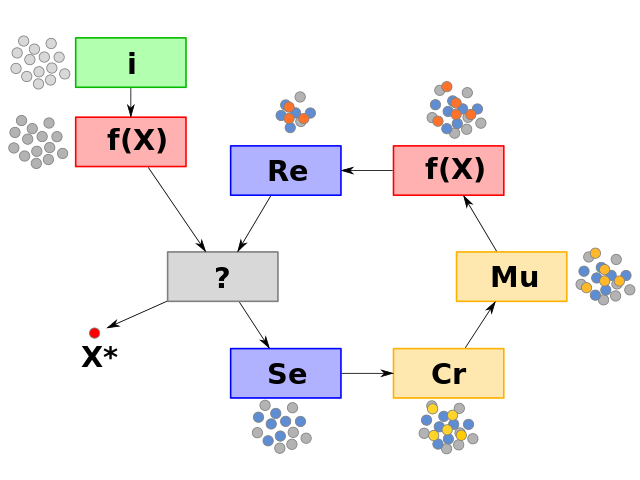

* **Inicialització** (I). Es genera aleatòriament una població inicial, constituïda per un conjunt de cromosomes (o també anomenats gens) que representen possibles solucions del problema. Aquesta població haurà de tenir una diversitat inicial prou rica per a garantir que l'algorisme no convergeixi de forma prematura en solucions no òptimes.
* **Avaluació** (A). Per a cadascun dels cromosomes, l'avaluarem a l'espai de cerca (aplicarem la funció que desitgem optimitzar) i, després, calcularem la distància a la solució que volem obtenir. Aquesta solució objectiu és molt important i està codificada en la funció de fitness que dirigirà l'evolució cap a aquesta solució òptima (la podem conèixer o no, en aquest segon cas, l'expressarem en forma de funció: com de ràpid és un cotxe, quina és la quantitat monetària més gran, etc.). A més, hem de definir les condicions de parada de l'algorisme per no entrar en un bucle infinit: acotant el nombre de passos de l'algorisme o quan ja no hi hagi canvis en la població.
* **Selecció** (Se). Si no s'ha donat la condició de parada, es procedeix a escollir els cromosomes que es creuaran en la següent generació. Per a això, seleccionarem els millors cromosomes, ordenant-los per la seva aptitud.
* **Encreuament** (En). En aquesta metàfora, representa la reproducció sexual i opera sobre dos cromosomes alhora per a generar dos descendents, en què es combinen les característiques d'ambdós cromosomes pares.
* **Mutació** (Mu). Modifica de forma aleatòria una part del cromosoma dels individus de la població per a afegir diversitat i poder sortir de pous locals a l'espai de cerca.
* **Reemplaçament** (Re). Una vegada aplicats els operadors genètics, se seleccionen els millors individus per a conformar la població de la següent generació i continuar amb un altre pas de la simulació.


### Exercici 1 **<font color="gold" size="+2">CI</font>**
El codi següent és una implementació d'un algorisme genètic que optimitza la cerca d'un string, és a dir, donat un string **objectiu**, intenta trobar aquesta cadena començant des de diverses cadenes amb caràcters aleatoris.

In [2]:
import random
import string


objectiu = "bioinformatics_programming"


GENS = 50
MAX_GENERACIO = 20000


class Individu(object):
    def __init__(self, adn, fitness):
        self.adn = adn
        self.fitness = fitness


def calcular_fitness(orige, valor_objectiu):
    fitness = 0
    for i in range(0, len(orige)):
        fitness += (ord(valor_objectiu[i]) - ord(orige[i])) ** 2
    return fitness


def mutacio(pare1, pare2):
    adn_fill = pare1.adn[:]

    start = random.randint(0, len(pare2.adn) - 1)
    stop = random.randint(0, len(pare2.adn) - 1)
    if start > stop:
        stop, start = start, stop

    adn_fill[start:stop] = pare2.adn[start:stop]

    posicio = random.randint(0, len(adn_fill) - 1)
    adn_fill[posicio] = chr(ord(adn_fill[posicio]) + random.randint(-1, 1))
    fitness_fill = calcular_fitness(adn_fill, objectiu)
    return Individu(adn_fill, fitness_fill)


def pare_a_latzar(poblacio):
    return poblacio[int(random.random() * random.random() * (GENS - 1))]


def escriu_generacio(generacio, poblacio):
    print('Passos de simulació: %d' % generacio)
    print()
    print('  Fitness         ADN')
    print('------------------------')
    for candidat in poblacio:
        print("%6i %15s" % (candidat.fitness, ''.join(candidat.adn)))
    print()


def inicialitza_poblacio():
    poblacio = []
    for i in range(0, GENS):
        adn = [random.choice(string.printable[:-5]) for _ in range(0, len(objectiu))]
        fitness = calcular_fitness(adn, objectiu)
        candidate = Individu(adn, fitness)
        poblacio.append(candidate)
    return poblacio


def simulacio():
    poblacio = inicialitza_poblacio()
    generacio = 0
    while True and generacio < MAX_GENERACIO:
        generacio += 1
        poblacio.sort(key=lambda candidate: candidate.fitness)

        if poblacio[0].fitness == 0:
            break

        pare1 = pare_a_latzar(poblacio)
        pare2 = pare_a_latzar(poblacio)

        fill = mutacio(pare1, pare2)
        if fill.fitness < poblacio[-1].fitness:
            poblacio[-1] = fill

    if generacio == MAX_GENERACIO:
        print(u'S\'ha arribat al màxim de generacions')
    escriu_generacio(generacio, poblacio)


simulacio()

Passos de simulació: 8697

  Fitness         ADN
------------------------
     0 bioinformatics_programming
     1 biohnformatics_programming
     1 bioineormatics_programming
     1 bioineormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohnformatics_psogramming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 bioinfnrlatics_programming
     2 biohnformaticr_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohneormatics_programming
     2 biohnforlatics_programming
     2 bioineormatics_prngramming
     2 biohnforlatics_programming
     3 biohnenrmatics_programming
     3 bioinenrlatics_programming
     3 bioinenrlatics_programming
     3 b

És molt important, tant en bioinformàtica com en programació general, llegir i entendre el codi d'altres. Per això, en aquest exercici us demanem que comenteu el codi anterior amb comentaris en el propi codi que expliquin les parts més importants.

### Exercici 2 **<font color="green" size="+2">MU</font>**

Escriviu una funció de fitness alternativa a la funcio `calcular_fitness` de l'execrici1. Un afunció alternativa es refereix a un càlcul diferent del fitness. Un fitness=0 indica que la cadena objectiu s'ha aconseguit, és a dir que la vostra solució ha de complir aquesta mateixa norma. Expliqueu en què consisteix la vostra funció de fitness. Podeu copiar tot el codi de l'exercici 1 i fer les vostres modificacions de la funció `calcular_fitness()`.

In [7]:
# Resposta
def calcular_fitness_alternativa(orige, valor_objectiu):
    fitness = sum(1 for i, j in zip(orige, valor_objectiu) if i == j)
    return len(valor_objectiu) - fitness


Testeja que el teu codi és correcte amb el següent test *unitari*

In [8]:
%%ipytest
# Test Exercici 2
def test_fitness():
  assert calcular_fitness_alternativa("bioinformatics_programming", "bioinformatics_programming") == 0
  assert calcular_fitness_alternativa("bioinpormatics_porgrammang", "bioinformatics_programming") > 0
  assert calcular_fitness_alternativa("bbbbbbbbbbbbbb_ppppppppppp", "bioinformatics_programming") > calcular_fitness_alternativa("bioinpormatics_porgrammang", "bioinformatics_programming")

.                                                                                            [100%]
1 passed in 0.11s


### Exercici 3 **<font color="green" size="+2">MU</font>**

Representeu, utilitzant matplotlib, el fitness màxim, el mínim i la mitjana per passos de la simulació en un gràfic.
Copieu i pegueu el codi de l'exercici 1 i feu les modificacions pertinents perquè les dades que necessiteu representar es guardin a cada pas de la simulació.

Heu d'usar la funció de fitness de l'exercici 1 , no la que heu definit en l'exercici 2.

El resultat ha de ser similar al gràfic següent:

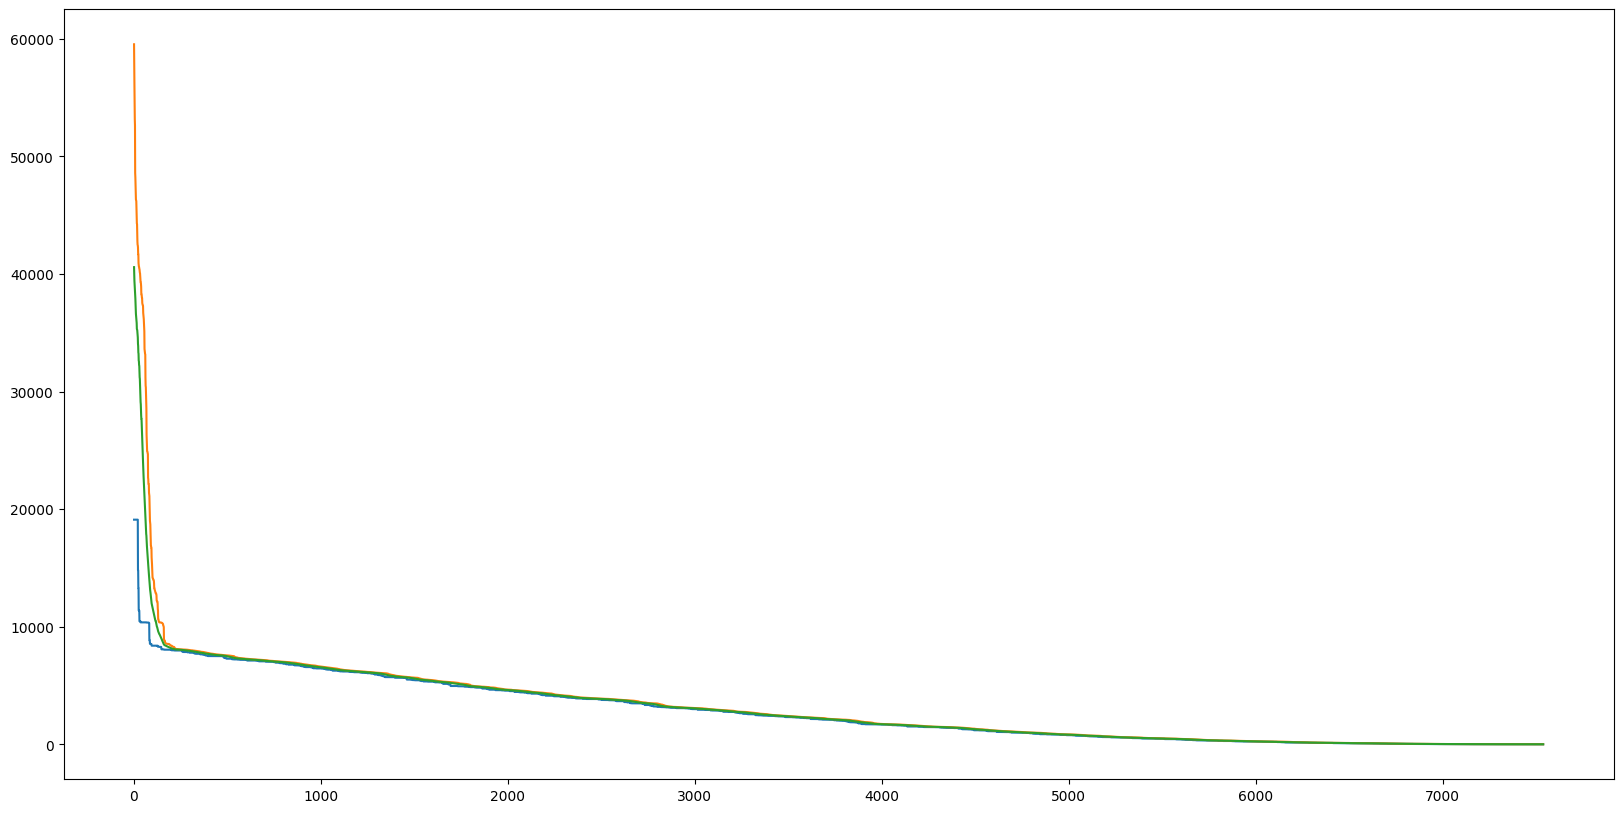

Passos de simulació: 6917

  Fitness         ADN
------------------------
     0 bioinformatics_programming
     1 bioinformatics_programmhng
     1 bioinformatics_programmhng
     2 bioinformatics_proframmhng
     2 bioinformatics_proframmimg
     2 bioinformatics_programmhnh
     2 bioingormatics_programmhng
     2 bioinformatics_proframmimg
     2 bioingormatics_programmhng
     2 bioinformbtics_programmhng
     2 bioinformbtics_programmhng
     2 bioinformatics_programmhnh
     2 bioinformatics_programmhnh
     2 bioinformbtics_progr`mming
     2 bioinformatics_proframmhng
     2 biohnformatics_programmhng
     2 bioinformatics_programmhnh
     2 bioinformatics_proframmhng
     2 bioinformatics_programmhnh
     2 aioinformatics_programmhng
     2 bioingormatics_programmhng
     2 bioinformatics_programmhnh
     2 biohnformatics_programmimg
     2 bioingormatics_programmhng
     2 bioinformatics_programmhnh
     2 bioinformatics^programmhng
     2 bioinformatics_programmhnh
     3 b

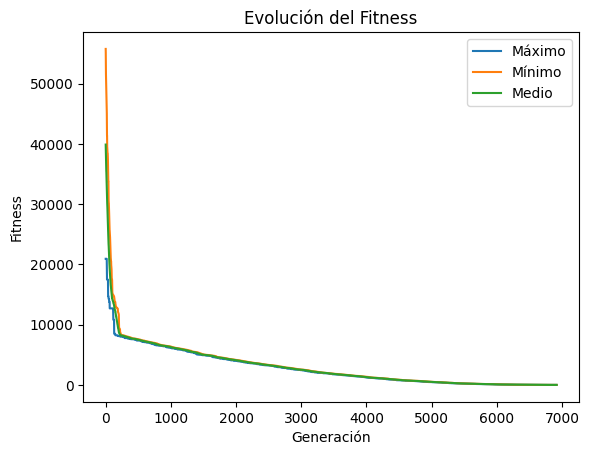

In [9]:
%matplotlib inline

# Resposta
import random
import string
import matplotlib.pyplot as plt

objectiu = "bioinformatics_programming"

GENS = 50
MAX_GENERACIO = 20000


class Individu(object):
    def __init__(self, adn, fitness):
        self.adn = adn
        self.fitness = fitness


def calcular_fitness(orige, valor_objectiu):
    fitness = 0
    for i in range(0, len(orige)):
        fitness += (ord(valor_objectiu[i]) - ord(orige[i])) ** 2
    return fitness


def mutacio(pare1, pare2):
    adn_fill = pare1.adn[:]

    start = random.randint(0, len(pare2.adn) - 1)
    stop = random.randint(0, len(pare2.adn) - 1)
    if start > stop:
        stop, start = start, stop

    adn_fill[start:stop] = pare2.adn[start:stop]

    posicio = random.randint(0, len(adn_fill) - 1)
    adn_fill[posicio] = chr(ord(adn_fill[posicio]) + random.randint(-1, 1))
    fitness_fill = calcular_fitness(adn_fill, objectiu)
    return Individu(adn_fill, fitness_fill)


def pare_a_latzar(poblacio):
    return poblacio[int(random.random() * random.random() * (GENS - 1))]


def escriu_generacio(generacio, poblacio):
    print('Passos de simulació: %d' % generacio)
    print()
    print('  Fitness         ADN')
    print('------------------------')
    for candidat in poblacio:
        print("%6i %15s" % (candidat.fitness, ''.join(candidat.adn)))
    print()


def inicialitza_poblacio():
    poblacio = []
    for i in range(0, GENS):
        adn = [random.choice(string.printable[:-5]) for _ in range(0, len(objectiu))]
        fitness = calcular_fitness(adn, objectiu)
        candidate = Individu(adn, fitness)
        poblacio.append(candidate)
    return poblacio


def simulacio():
    poblacio = inicialitza_poblacio()
    generacio = 0

    fitness_maximos = []
    fitness_minimos = []
    fitness_medios = []

    while True and generacio < MAX_GENERACIO:
        generacio += 1
        poblacio.sort(key=lambda candidate: candidate.fitness)

        fitness_max = poblacio[0].fitness
        fitness_min = poblacio[-1].fitness
        fitness_medio = sum(candidate.fitness for candidate in poblacio) / len(poblacio)

        fitness_maximos.append(fitness_max)
        fitness_minimos.append(fitness_min)
        fitness_medios.append(fitness_medio)

        if poblacio[0].fitness == 0:
            break

        pare1 = pare_a_latzar(poblacio)
        pare2 = pare_a_latzar(poblacio)

        fill = mutacio(pare1, pare2)
        if fill.fitness < poblacio[-1].fitness:
            poblacio[-1] = fill

    if generacio == MAX_GENERACIO:
        print(u'S\'ha arribat al màxim de generacions')

    escriu_generacio(generacio, poblacio)

    # Representación gráfica del fitness máximo, mínimo y medio por generación
    plt.plot(range(1, generacio + 1), fitness_maximos, label='Máximo')
    plt.plot(range(1, generacio + 1), fitness_minimos, label='Mínimo')
    plt.plot(range(1, generacio + 1), fitness_medios, label='Medio')
    plt.xlabel('Generación')
    plt.ylabel('Fitness')
    plt.title('Evolución del Fitness')
    plt.legend()
    plt.show()


simulacio()


**Autoria**

Autors/es que han participat col·lectivament en aquesta obra:


*   Gabriel Felipe Rodríguez Lozano
*   Pau Andrio Balado
*   Brian Jiménez García
*   Melchor Sanchez Martinez
*   Julia Mir Pedrerol

**Data de creació**


*   Ultima modificació: Maig 2024